In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns                                         #импортируем все нужные нам библиотеки
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


получаем нужные нам данные из разных датасетов и объеденяем в один.
Мы будем предсказывать цену кейсов для долгосрочного инвестирования

In [2]:
names_df = pd.read_csv("csgoml/name_conversion_table.csv")

case_df = names_df[names_df["decoded name"].str.contains("Case",na=False)&
                   (~names_df['decoded name'].str.contains('Souvenir|Capsule|Package|Hardened|Key', na=False))]     

In [3]:
items_path = 'csgoml/items' 

all_dfs = [] 

for index, row in case_df.iterrows():
    encoded = row['URL encoded name']
    decoded = row['decoded name']
    file_path = os.path.join(items_path, f"{encoded}.csv")
    
    if os.path.exists(file_path):
        temp_df = pd.read_csv(file_path)                                            
        temp_df['case_name'] = decoded
        all_dfs.append(temp_df)
    else:
        print(f"Внимание: Файл для {decoded} не найден по пути {file_path}")
final_df = pd.concat(all_dfs, ignore_index=True)



Создаем дополнительные признаки для модели связанные со временем.Переделали дату в удобныем нам признаки.Создаем лаги на полгода так как волатильнась не сильная и если брать лаг меньше модель будет просто предсказывать
значения лага.

In [4]:
# Преобразуем unix-время в понятные признаки для модели
final_df["date_clean"] = pd.to_datetime(final_df["date"], format='%b %d %Y %H: +0' )
final_df["month"] = final_df["date_clean"].dt.month 
final_df["year"] = final_df["date_clean"].dt.year
final_df['day_of_week'] = final_df['date_clean'].dt.dayofweek                                              

release_dates = final_df.groupby('case_name')['unix timestamp'].min()
final_df['release_unix'] = final_df['case_name'].map(release_dates)
# Создаем признак "дней с момента выхода кейса" —  важно для прогноза цены
final_df['days_since_release'] = (final_df['unix timestamp'] - final_df['release_unix']) / 86400

final_df = final_df.sort_values(["case_name","unix timestamp"])
final_df["lags_180day"] = final_df.groupby("case_name")["price"].shift(180)        

создаем признак,чтобы понять редкий ли сейчас наш предмет,можно ли его получить просто за игру или только за реальные деньги


In [5]:
limit = final_df['quantity'].quantile(0.85) # Берем топ 15% самых массовых продаж
final_df['is_active_drop'] = (final_df['quantity'] > limit).astype(int)
final_df = final_df.drop(columns=["date","date_clean"])
final_df = final_df.dropna().reset_index(drop=True)


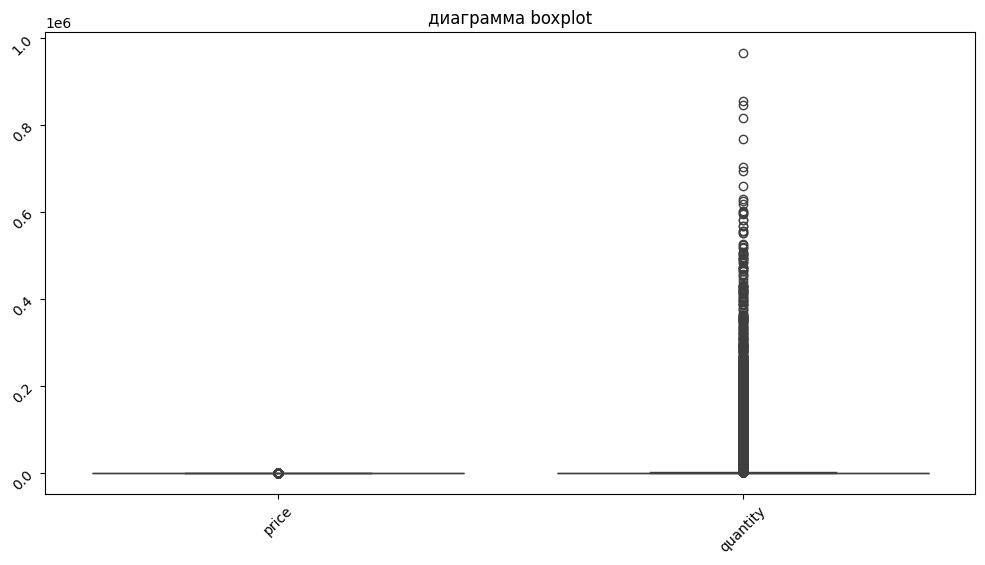

In [6]:
cols_to_show = ['price', 'quantity']


plt.figure(figsize =(12,6))
sns.boxplot(data=final_df[cols_to_show])
plt.title("диаграмма boxplot")
plt.tick_params(rotation=45) 

plt.show()


Для каждого кейса делаем ограничения по количсетву продаж,так как любой шум оттуда можно сильно повлиять на всплеск предсказний.Убираем только 2 процента,чтобы не здаеть важнейшие данные

In [7]:
limits = final_df.groupby("case_name")["quantity"].transform(lambda x: x.quantile(0.98))
final_df["quantity"] = final_df["quantity"].clip(upper=limits)


так как работаем с датами и предсказнием цен, для того чтобы не было утечки данных делим датасет таким образом а не используем train_test_split

In [8]:
final_df = final_df.sort_values("unix timestamp")
split_index = int(len(final_df)*0.8)
train_df = final_df.iloc[:split_index]
test_df = final_df.iloc[split_index:]
X_train = train_df.drop(columns=["price"])
y_train = train_df["price"]                              

X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]
print(train_df.shape,test_df.shape)

(420864, 11) (105216, 11)


Обучаем модель с помощью catboost , минимизируес метрику mae так как она не так сильно наказывает за выбросы

In [9]:
cat_features = ["case_name"]
catboost = CatBoostRegressor(iterations=1000,learning_rate=0.05,
                             loss_function="MAE",
                             verbose=100,eval_metric="MAE",l2_leaf_reg=10
                             )       
                                                                                     #обучаем модель с помощью catboost
catboost.fit(X_train,y_train,cat_features=cat_features)

0:	learn: 4.8782939	total: 270ms	remaining: 4m 29s
100:	learn: 0.5203272	total: 13.4s	remaining: 1m 59s
200:	learn: 0.4497846	total: 25.8s	remaining: 1m 42s
300:	learn: 0.4270740	total: 38.4s	remaining: 1m 29s
400:	learn: 0.4092831	total: 51.1s	remaining: 1m 16s
500:	learn: 0.3949867	total: 1m 3s	remaining: 1m 3s
600:	learn: 0.3803313	total: 1m 16s	remaining: 50.5s
700:	learn: 0.3589292	total: 1m 28s	remaining: 37.8s
800:	learn: 0.3495556	total: 1m 41s	remaining: 25.1s
900:	learn: 0.3364013	total: 1m 53s	remaining: 12.5s
999:	learn: 0.3259363	total: 2m 6s	remaining: 0us


In [10]:
y_pred= catboost.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)                                        
print(f"метрика mae: {mae:.4f}, метрика mape: {mape:.4f}")

метрика mae: 0.4836, метрика mape: 0.1169


выводим предсказания для нашего кейса,чтобы увидеть как видет себя модель 

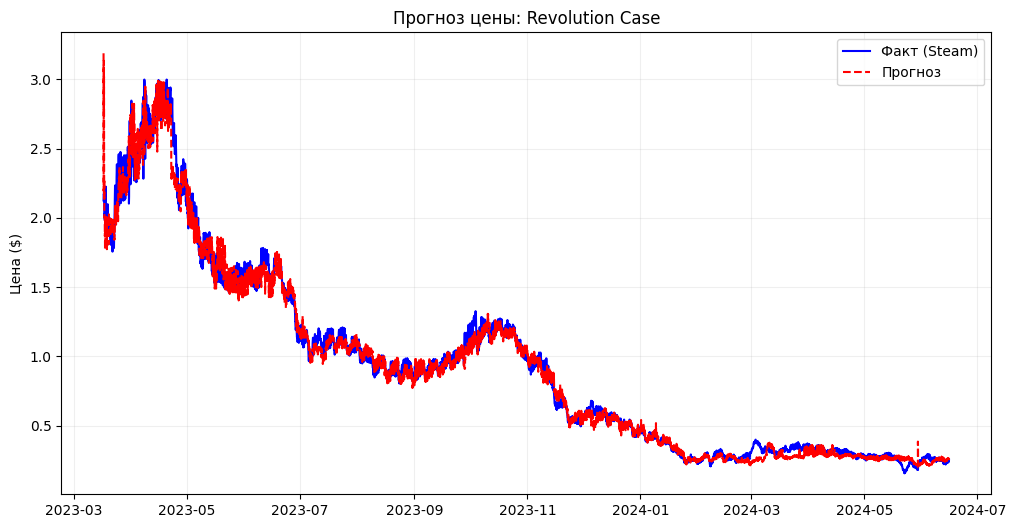

In [11]:
case_name = "Revolution Case" #взяли один рандомный кейс чтобы показать как выглядит наша модель
case_df = final_df[final_df['case_name'] == case_name].copy() 
case_df['date'] = pd.to_datetime(case_df['unix timestamp'], unit='s')
case_df = case_df.sort_values('date')


X_case = case_df.drop(columns=['price', 'date'])
case_preds = catboost.predict(X_case) 


plt.figure(figsize=(12, 6))
plt.plot(case_df['date'], case_df['price'], label='Факт (Steam)', color='blue')
plt.plot(case_df['date'], case_preds, label='Прогноз', color='red', linestyle='--')

plt.title(f'Прогноз цены: {case_name}')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [17]:
final_df["price"].describe() #доказывает что есть большой разброс цены у кейсов какие то стоят по 90 долларов,другие могут стоить буквально несколько центов

count    526080.000000
mean          5.689920
std          12.857154
min           0.030000
25%           0.635000
50%           1.837000
75%           4.644000
max          93.404000
Name: price, dtype: float64

Анализ результатов: Модель CatBoost показаламетрика mae: 0.4836, метрика mape: 0.1169 что является отличным результатом,метрика mape была быть еще лучше,но у нас слишком сильна спекулируется цена на дешевых кейсах за один день цена может меняется почти на 50 процентов из за спекуляции и обновлений в игре,что сильно влияют на рынок.

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#у xgboost есть другой способ работы с категоиальными значениями,но у него он плохо сработал и выдал ужасные метрики
#Обучаем его на ВСЕХ названиях кейсов (из final_df), 
# чтобы он знал все возможные варианты
final_df['case_name'] = le.fit_transform(final_df['case_name'].astype(str))


train_df = final_df.iloc[:split_index]
test_df = final_df.iloc[split_index:]

X_train = train_df.drop(columns=["price"])
y_train = train_df["price"]
X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]
print(train_df.shape,test_df.shape)

(420864, 11) (105216, 11)


In [13]:
xgboost = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6, 
    objective="reg:squarederror",
    
    
)
xgboost.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
y_pred_xg = xgboost.predict(X_test)
mae = mean_absolute_error(y_test,y_pred_xg)
mape = mean_absolute_percentage_error(y_test,y_pred_xg)                                         #получаем нужные нам метрики, метрика mape получилась настолько большая так как в игре бывают обновления,которые резко вызывают колебание цены
print(f"метрика mae: {mae:.4f}, метрика mape: {mape:.4f}") 

метрика mae: 0.7809, метрика mape: 0.1495


Получили неплохие результаты с xgboost,модель сработала буквально за секунды в отличии от catboost , но так как наша цель это инвестирование и предсказания цены,то точность важнее скорости,поэтому выбираем catboost

In [ ]:
catboost.save_model("best_model.cbm")